# Tugas - Klasifikasi dengan Support Vector Machine (SVM)

| Nama | NRP |
|------|-----|
| Rafa Rizki Aira Swala | 5054251017 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model SVM Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja SVM secara praktik, khususnya:
1. Perbedaan hasil antara kernel Linear dan kernel RBF
2. Pengaruh parameter `C` dan `gamma` terhadap gejala overfitting/underfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model SVM dengan kernel Linear dan kernel RBF.
   - Lakukan eksperimen regularisasi dengan variasi nilai `C` dan `gamma`.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [26]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [27]:
# Load dataset dan tampilkan informasi dasar
df = pd.read_csv('breast_cancer.csv')

# Drop kolom yang tidak diperlukan
# - 'Unnamed: 32' muncul karena trailing comma di CSV, isinya kosong semua
# - 'id' hanya identifier, tidak berguna untuk klasifikasi
df = df.drop(columns=['Unnamed: 32', 'id'])

print("Jumlah baris dan kolom:", df.shape)
print("\nTipe data:")
print(df.dtypes)
print("\nStatistik deskriptif:")
print(df.describe())
print("\nJumlah missing value per kolom:")
print(df.isnull().sum())
print("\nTotal missing value:", df.isnull().sum().sum())

Jumlah baris dan kolom: (569, 31)

Tipe data:
diagnosis                      str
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity

Kolom target: diagnosis

Distribusi kelas target:
diagnosis
B    357
M    212
Name: count, dtype: int64


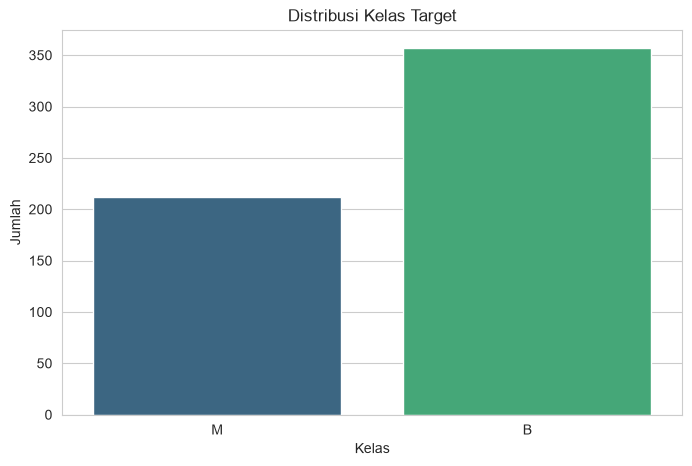

In [28]:
# Tampilkan distribusi kelas target dalam bentuk bar plot
target_col = 'diagnosis'   # <-- eksplisit, jangan pakai df.columns[-1]
print("Kolom target:", target_col)
print("\nDistribusi kelas target:")
print(df[target_col].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(x=target_col, data=df, palette='viridis')
plt.title('Distribusi Kelas Target')
plt.xlabel('Kelas')
plt.ylabel('Jumlah')
plt.show()

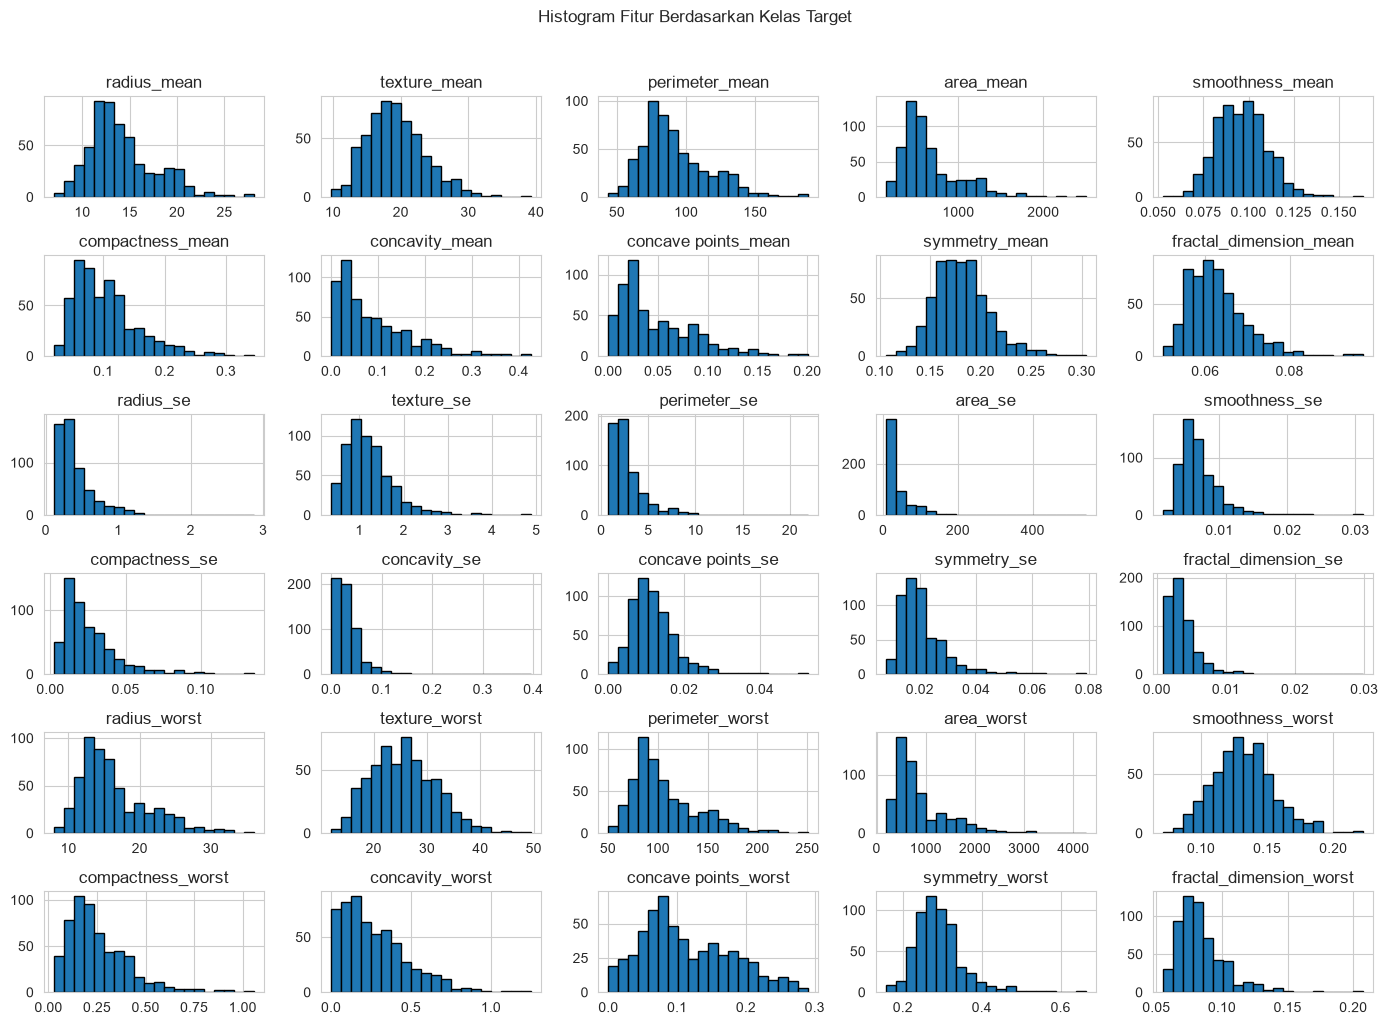

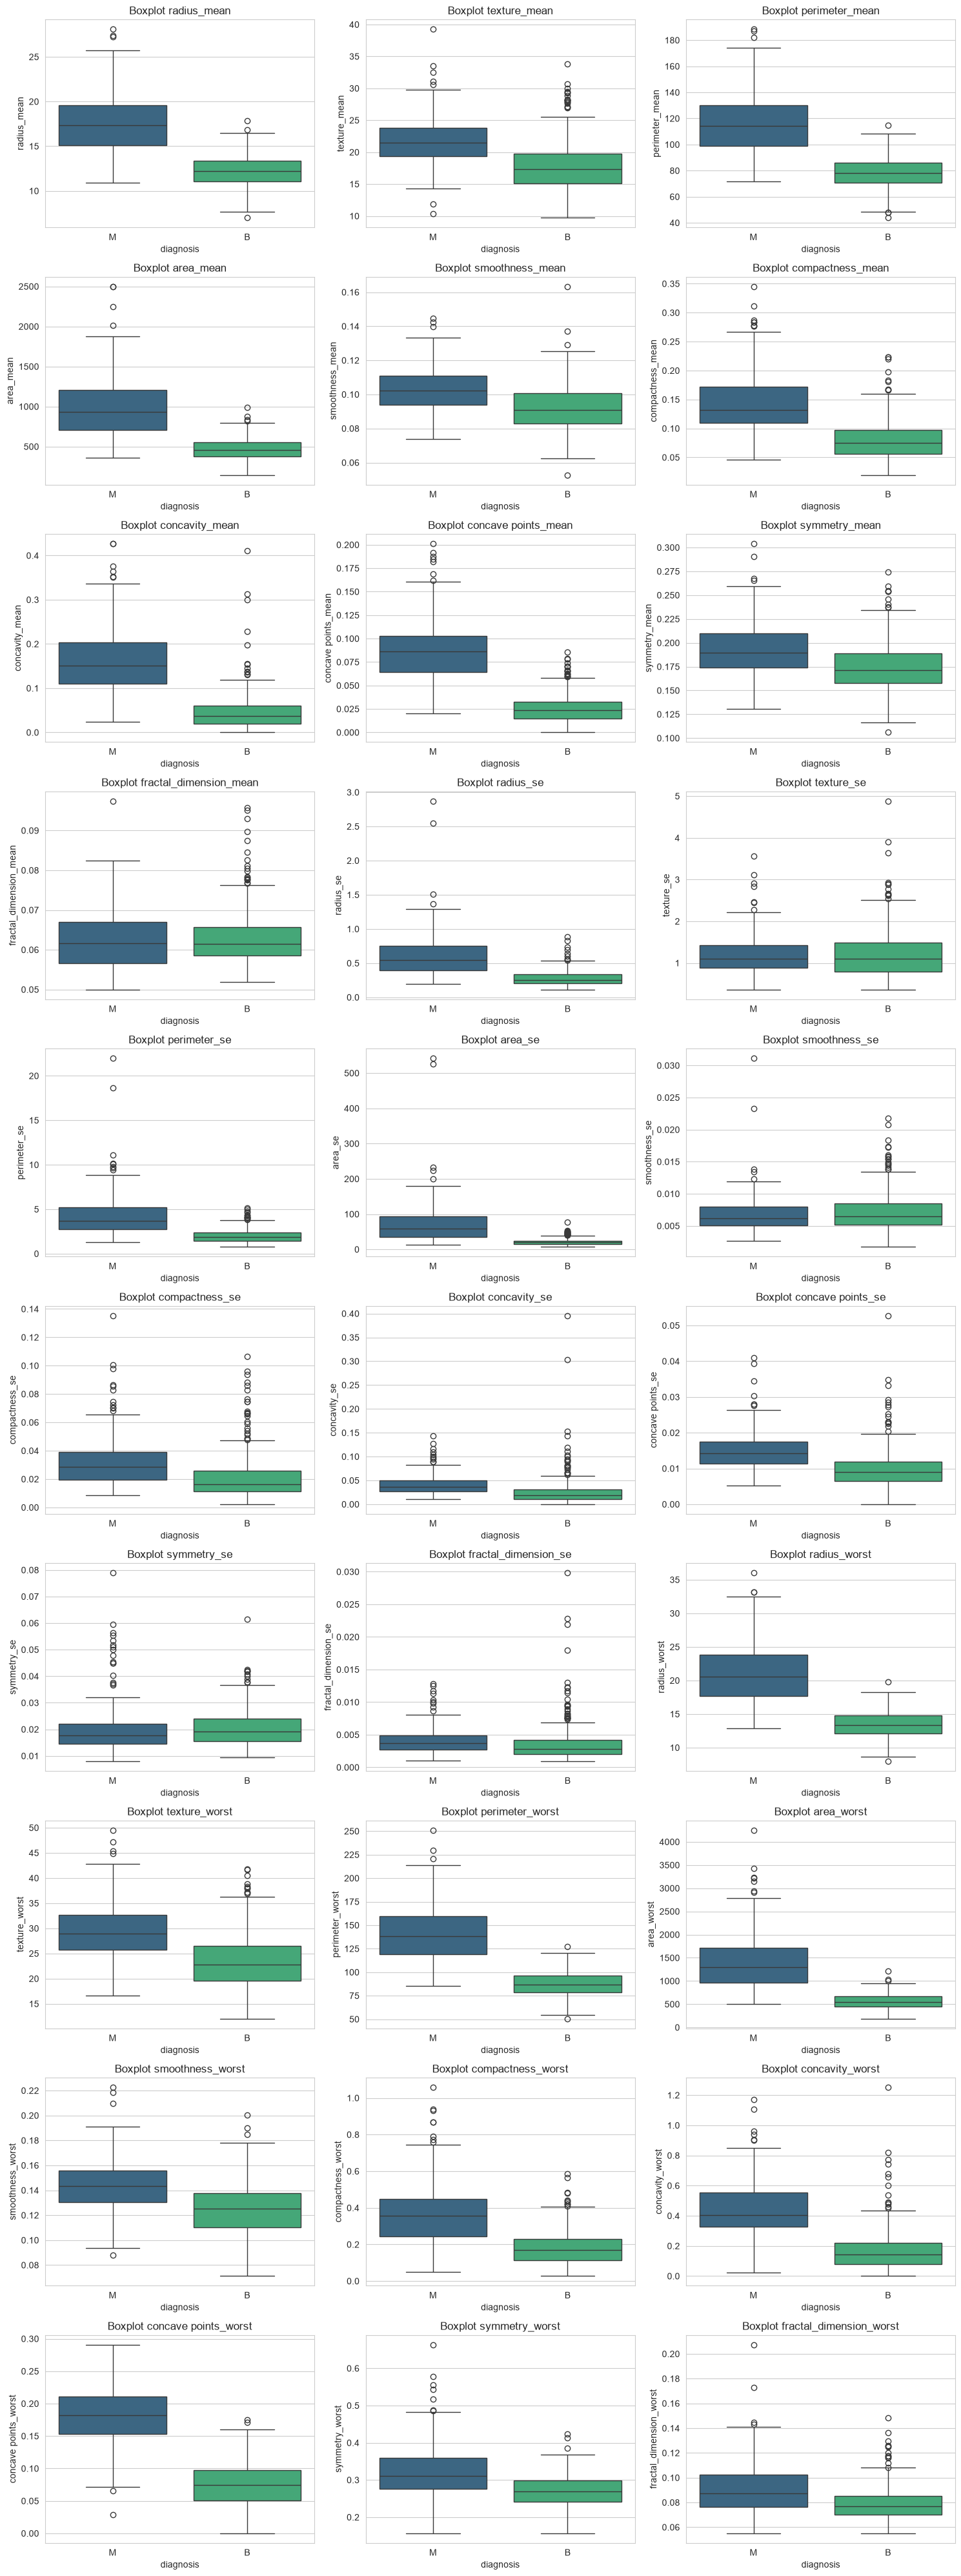

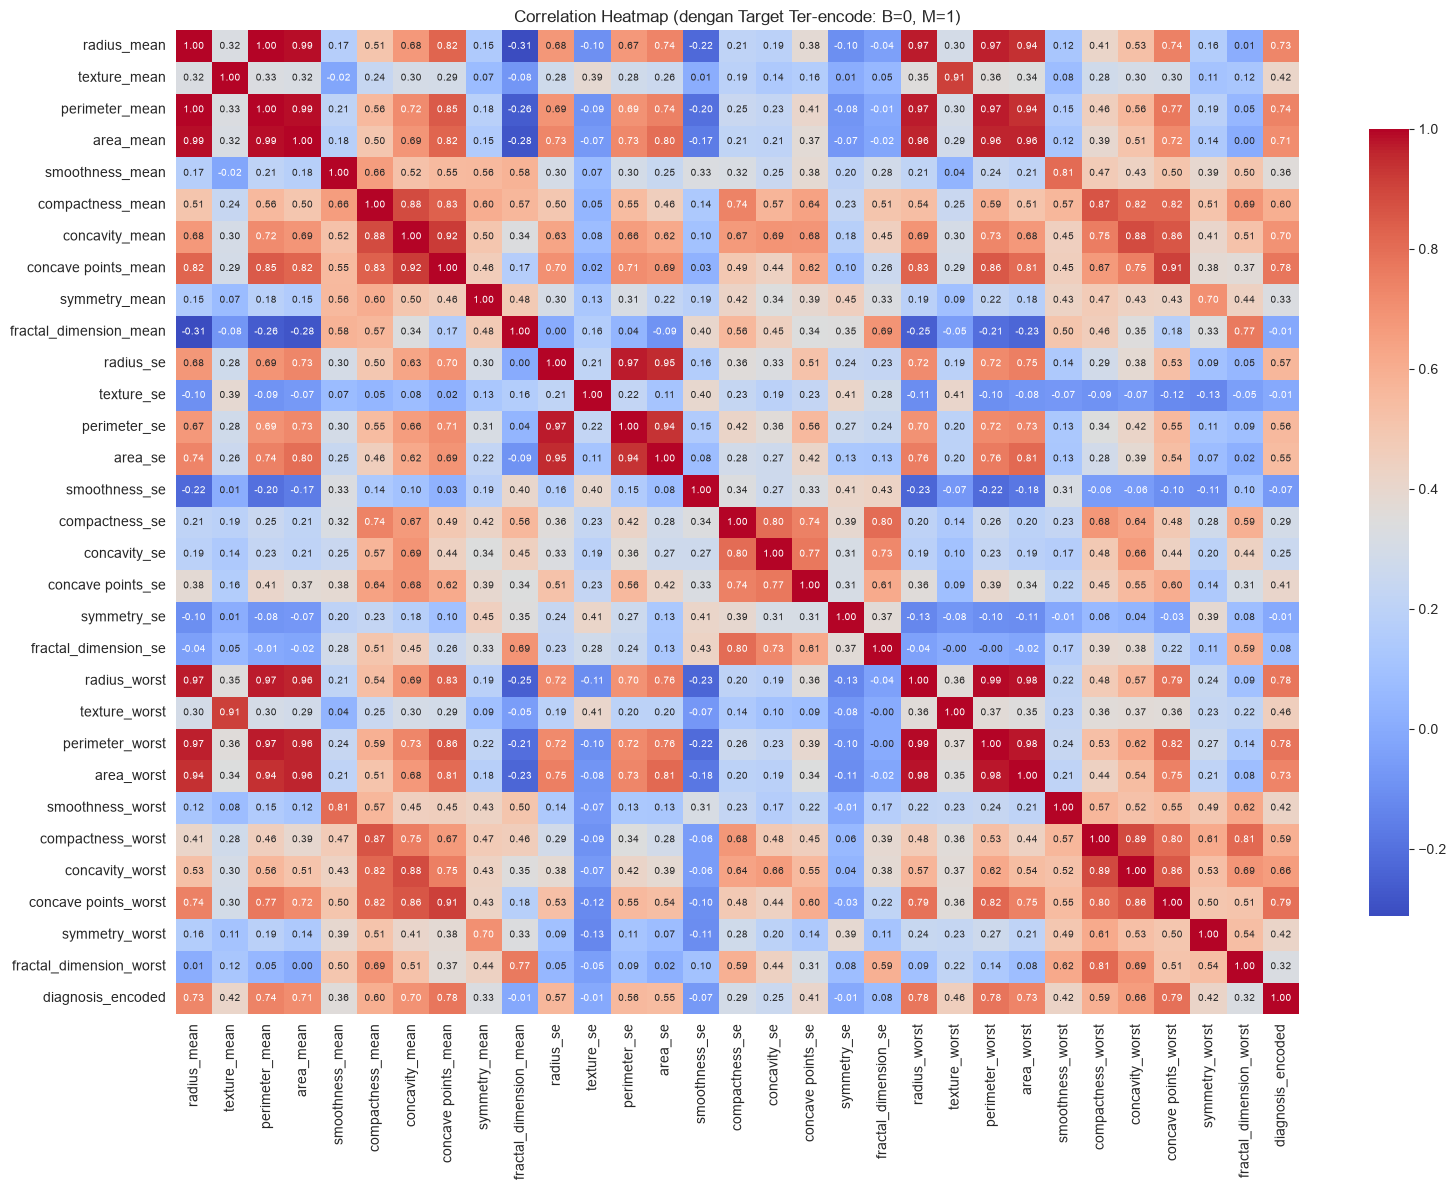

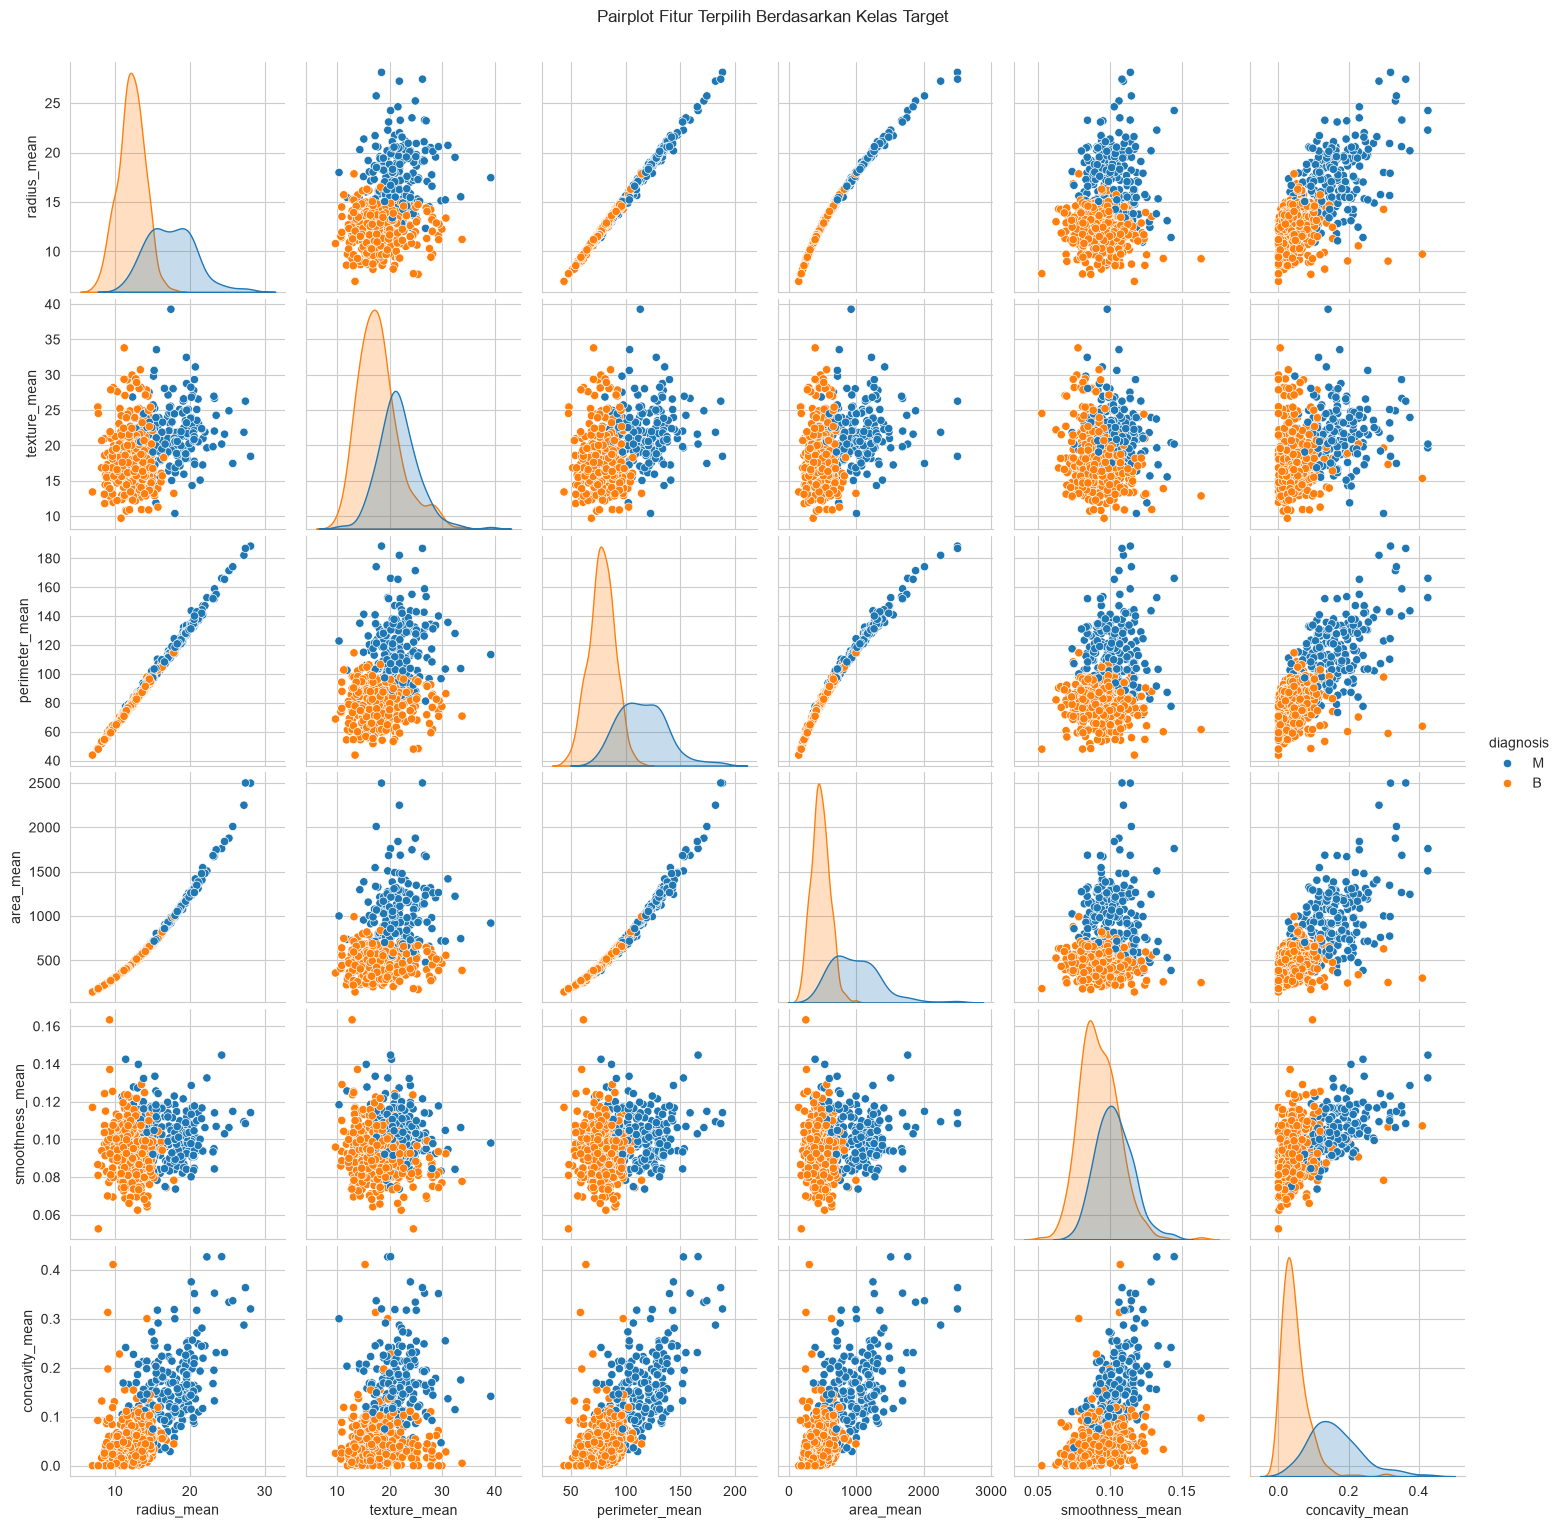

In [29]:
# Tampilkan distribusi atau hubungan antar fitur, dibedakan berdasarkan kelas target
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

# Histogram per fitur berdasarkan kelas
df[numeric_cols + [target_col]].hist(figsize=(14, 10), bins=20, edgecolor='black')
plt.suptitle('Histogram Fitur Berdasarkan Kelas Target', y=1.02)
plt.tight_layout()
plt.show()

# Boxplot per fitur berdasarkan kelas
n_features = len(numeric_cols)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=target_col, y=col, data=df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Boxplot {col}')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Correlation heatmap termasuk target (target di-encode dulu jadi numerik: B=0, M=1)
df_corr = df[numeric_cols].copy()
df_corr['diagnosis_encoded'] = (df[target_col] == 'M').astype(int)

plt.figure(figsize=(16, 12))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt='.2f',
            annot_kws={'size': 7}, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap (dengan Target Ter-encode: B=0, M=1)')
plt.tight_layout()
plt.show()

# Pairplot (dibatasi fitur terpilih agar tidak terlalu berat)
selected_features = ['radius_mean', 'texture_mean', 'perimeter_mean',
                     'area_mean', 'smoothness_mean', 'concavity_mean']

sns.pairplot(df[selected_features + [target_col]], hue=target_col, diag_kind='kde')
plt.suptitle('Pairplot Fitur Terpilih Berdasarkan Kelas Target', y=1.02)
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [30]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

print("Jumlah missing value sebelum penanganan:")
print(df.isnull().sum())

# Pisahkan dulu fitur dan target sebelum handling missing value
# agar tidak terjadi data leakage
X_raw = df.drop(columns=[target_col])
y_raw = df[target_col]

# Cek tipe kolom
numeric_features = X_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_raw.select_dtypes(exclude=[np.number]).columns.tolist()

print("\nFitur numerik:", numeric_features)
print("Fitur kategorikal:", categorical_features)

# Tangani missing value:
# - Numerik: isi dengan median (robust terhadap outlier)
# - Kategorikal: isi dengan modus
if X_raw.isnull().sum().sum() > 0:
    for col in numeric_features:
        if X_raw[col].isnull().sum() > 0:
            X_raw[col] = X_raw[col].fillna(X_raw[col].median())
    for col in categorical_features:
        if X_raw[col].isnull().sum() > 0:
            X_raw[col] = X_raw[col].fillna(X_raw[col].mode()[0])
    print("\nMissing value telah ditangani.")
else:
    print("\nTidak ada missing value, tidak perlu penanganan.")

print("\nJumlah missing value setelah penanganan:")
print(X_raw.isnull().sum().sum())

Jumlah missing value sebelum penanganan:
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

Fitur numerik: ['radius_mean', 'texture_mean',

In [31]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai
# (misalnya One-Hot Encoding atau Ordinal Encoding).

if len(categorical_features) > 0:
    print("Melakukan One-Hot Encoding pada fitur kategorikal:", categorical_features)
    X_encoded = pd.get_dummies(X_raw, columns=categorical_features, drop_first=True)
else:
    print("Tidak ada fitur kategorikal, tidak perlu encoding.")
    X_encoded = X_raw.copy()

# Encode target jika masih berupa string/kategorikal
# Gunakan dtype.kind untuk deteksi yang lebih robust:
# 'O' = object, 'U' = unicode string, 'S' = byte string
if y_raw.dtype.kind in ('O', 'U', 'S'):
    le = LabelEncoder()
    y_encoded = le.fit_transform(y_raw)
    print("\nTarget di-encode dengan LabelEncoder.")
    print("Mapping kelas:", dict(zip(le.classes_, le.transform(le.classes_))))
else:
    y_encoded = y_raw.values
    print("\nTarget sudah numerik, tidak perlu encoding.")

print("\nShape X setelah encoding:", X_encoded.shape)
print("Shape y:", y_encoded.shape)
print("Tipe data y:", y_encoded.dtype)

Tidak ada fitur kategorikal, tidak perlu encoding.

Target di-encode dengan LabelEncoder.
Mapping kelas: {'B': np.int64(0), 'M': np.int64(1)}

Shape X setelah encoding: (569, 30)
Shape y: (569,)
Tipe data y: int64


In [32]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

X = X_encoded
y = y_encoded

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Shape X_train:", X_train.shape)
print("Shape X_test :", X_test.shape)
print("Shape y_train:", y_train.shape)
print("Shape y_test :", y_test.shape)

print("\nDistribusi kelas di y_train:")
print(pd.Series(y_train).value_counts(normalize=True))
print("\nDistribusi kelas di y_test:")
print(pd.Series(y_test).value_counts(normalize=True))

Shape X_train: (455, 30)
Shape X_test : (114, 30)
Shape y_train: (455,)
Shape y_test : (114,)

Distribusi kelas di y_train:
0    0.626374
1    0.373626
Name: proportion, dtype: float64

Distribusi kelas di y_test:
0    0.631579
1    0.368421
Name: proportion, dtype: float64


**Catatan penting:** SVM adalah algoritma berbasis jarak (margin dihitung dari posisi antar titik data), sehingga sangat sensitif terhadap skala fitur. Fitur dengan rentang nilai besar bisa mendominasi perhitungan jarak meskipun sebenarnya tidak lebih penting. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [33]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Konversi kembali ke DataFrame agar mudah dibaca (opsional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Statistik X_train setelah scaling:")
print(X_train_scaled.describe().loc[['mean', 'std']].round(3))
print("\nStatistik X_test setelah scaling:")
print(X_test_scaled.describe().loc[['mean', 'std']].round(3))

Statistik X_train setelah scaling:
      radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
mean       -0.000         0.000           0.000     -0.000            0.000   
std         1.001         1.001           1.001      1.001            1.001   

      compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
mean            -0.000          -0.000                0.000          0.000   
std              1.001           1.001                1.001          1.001   

      fractal_dimension_mean  ...  radius_worst  texture_worst  \
mean                   0.000  ...        -0.000          0.000   
std                    1.001  ...         1.001          1.001   

      perimeter_worst  area_worst  smoothness_worst  compactness_worst  \
mean           -0.000      -0.000            -0.000             -0.000   
std             1.001       1.001             1.001              1.001   

      concavity_worst  concave points_worst  symmetry_worst  \
mean   

# 3. Eksperimen Model

## 3.1 SVM dengan Kernel Linear

Kernel Linear mencari hyperplane pemisah berupa garis/bidang lurus, tanpa proyeksi ke dimensi yang lebih tinggi. Cocok digunakan sebagai baseline, terutama jika dari hasil EDA data terlihat cukup terpisah secara linear.

In [34]:
# Inisialisasi dan latih model SVC dengan kernel='linear' menggunakan train set (yang sudah discaling).

C_value = 1.0  # nilai C default, digunakan sama untuk Linear dan RBF agar perbandingan adil

svm_linear = SVC(kernel='linear', C=C_value, random_state=42)
svm_linear.fit(X_train_scaled, y_train)

print("Model SVM kernel Linear selesai dilatih.")
print("Parameter:", svm_linear.get_params())

Model SVM kernel Linear selesai dilatih.
Parameter: {'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'linear', 'max_iter': -1, 'probability': 'deprecated', 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}


In [35]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.

y_pred_linear = svm_linear.predict(X_test_scaled)
y_train_pred_linear = svm_linear.predict(X_train_scaled)

print("Contoh prediksi test (10 pertama):", y_pred_linear[:10])
print("Akurasi train (Linear):", accuracy_score(y_train, y_train_pred_linear))
print("Akurasi test  (Linear):", accuracy_score(y_test, y_pred_linear))

Contoh prediksi test (10 pertama): [0 1 0 0 0 0 1 0 0 0]
Akurasi train (Linear): 0.989010989010989
Akurasi test  (Linear): 0.9649122807017544


## 3.2 SVM dengan Kernel RBF

Kernel RBF (Radial Basis Function) memproyeksikan data ke ruang berdimensi lebih tinggi melalui kernel trick, sehingga mampu menangani batas keputusan yang non-linear.

In [36]:
# Inisialisasi dan latih model SVC dengan kernel='rbf' menggunakan train set.
# Gunakan nilai hyperparameter lain (C) yang sama seperti model Linear di atas, agar perbandingan adil.

svm_rbf = SVC(kernel='rbf', C=C_value, gamma='scale', random_state=42)
svm_rbf.fit(X_train_scaled, y_train)

print("Model SVM kernel RBF selesai dilatih.")
print("Parameter:", svm_rbf.get_params())

Model SVM kernel RBF selesai dilatih.
Parameter: {'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': 'deprecated', 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}


In [37]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.

y_pred_rbf = svm_rbf.predict(X_test_scaled)
y_train_pred_rbf = svm_rbf.predict(X_train_scaled)

print("Contoh prediksi test (10 pertama):", y_pred_rbf[:10])
print("Akurasi train (RBF):", accuracy_score(y_train, y_train_pred_rbf))
print("Akurasi test  (RBF):", accuracy_score(y_test, y_pred_rbf))

Contoh prediksi test (10 pertama): [0 1 0 0 0 0 1 0 0 0]
Akurasi train (RBF): 0.9868131868131869
Akurasi test  (RBF): 0.9736842105263158


## 3.3 Eksperimen Regularisasi: Pengaruh C dan Gamma terhadap Overfitting

Parameter `C` mengatur trade-off antara margin lebar dan toleransi kesalahan klasifikasi, sedangkan `gamma` (khusus kernel RBF) mengatur seberapa lokal pengaruh tiap titik data. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai `C` (dan/atau `gamma`) memengaruhi akurasi training dan testing.

In [38]:
# Latih beberapa model SVC (kernel RBF) dengan variasi nilai C,
# misalnya 0.01, 0.1, 1, 10, 100.
# Gunakan gamma='scale' atau nilai gamma tetap agar perbandingan fokus pada pengaruh C.

C_values = [0.01, 0.1, 1, 10, 100]

results_C = {
    'C': [],
    'train_acc': [],
    'test_acc': []
}

for C in C_values:
    model = SVC(kernel='rbf', C=C, gamma='scale', random_state=42)
    model.fit(X_train_scaled, y_train)
    
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    
    results_C['C'].append(C)
    results_C['train_acc'].append(train_acc)
    results_C['test_acc'].append(test_acc)
    
    print(f"C={C:<6} | Train Acc={train_acc:.4f} | Test Acc={test_acc:.4f}")

C=0.01   | Train Acc=0.6264 | Test Acc=0.6316
C=0.1    | Train Acc=0.9538 | Test Acc=0.9474
C=1      | Train Acc=0.9868 | Test Acc=0.9737
C=10     | Train Acc=0.9890 | Test Acc=0.9737
C=100    | Train Acc=1.0000 | Test Acc=0.9649


In [39]:
# Hitung akurasi pada train set dan test set untuk setiap nilai C yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.

results_df = pd.DataFrame(results_C)
print(results_df)

        C  train_acc  test_acc
0    0.01   0.626374  0.631579
1    0.10   0.953846  0.947368
2    1.00   0.986813  0.973684
3   10.00   0.989011  0.973684
4  100.00   1.000000  0.964912


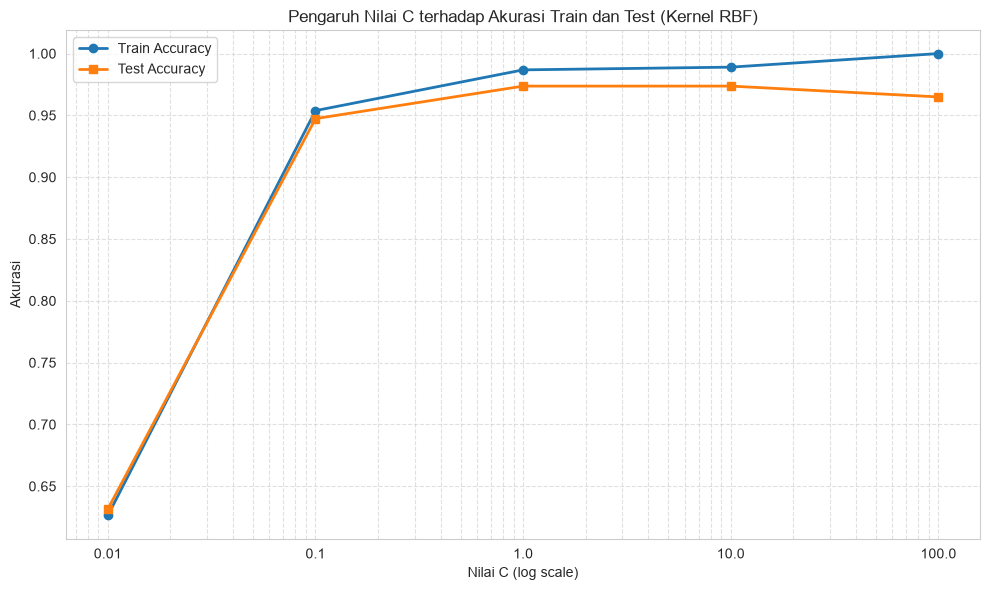


Gap (Train - Test) per nilai C:
C=0.01   | Train=0.6264 | Test=0.6316 | Gap=-0.0052
C=0.1    | Train=0.9538 | Test=0.9474 | Gap=0.0065
C=1.0    | Train=0.9868 | Test=0.9737 | Gap=0.0131
C=10.0   | Train=0.9890 | Test=0.9737 | Gap=0.0153
C=100.0  | Train=1.0000 | Test=0.9649 | Gap=0.0351


In [40]:
# Plot grafik akurasi training vs testing terhadap nilai C (gunakan sumbu x logaritmik) dalam satu chart.
# Amati pada nilai C berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).

plt.figure(figsize=(10, 6))
plt.plot(results_df['C'], results_df['train_acc'], marker='o', label='Train Accuracy', linewidth=2)
plt.plot(results_df['C'], results_df['test_acc'], marker='s', label='Test Accuracy', linewidth=2)

plt.xscale('log')
plt.xlabel('Nilai C (log scale)')
plt.ylabel('Akurasi')
plt.title('Pengaruh Nilai C terhadap Akurasi Train dan Test (Kernel RBF)')
plt.xticks(results_df['C'], labels=[str(c) for c in results_df['C']])
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Identifikasi gejala overfitting
gap = results_df['train_acc'] - results_df['test_acc']
print("\nGap (Train - Test) per nilai C:")
for c, g, tr, te in zip(results_df['C'], gap, results_df['train_acc'], results_df['test_acc']):
    print(f"C={c:<6} | Train={tr:.4f} | Test={te:.4f} | Gap={g:.4f}")

# 4. Evaluasi Model

In [41]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model kernel Linear dan RBF.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.

def get_metrics(y_true, y_pred, average='weighted'):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average=average, zero_division=0),
        'Recall': recall_score(y_true, y_pred, average=average, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, average=average, zero_division=0)
    }

metrics_linear = get_metrics(y_test, y_pred_linear)
metrics_rbf = get_metrics(y_test, y_pred_rbf)

comparison_df = pd.DataFrame({
    'Linear': metrics_linear,
    'RBF': metrics_rbf
}).T

comparison_df = comparison_df.round(4)
print("Perbandingan Metrik Evaluasi (Test Set):")
print(comparison_df)

Perbandingan Metrik Evaluasi (Test Set):
        Accuracy  Precision  Recall  F1-Score
Linear    0.9649     0.9668  0.9649    0.9645
RBF       0.9737     0.9747  0.9737    0.9735


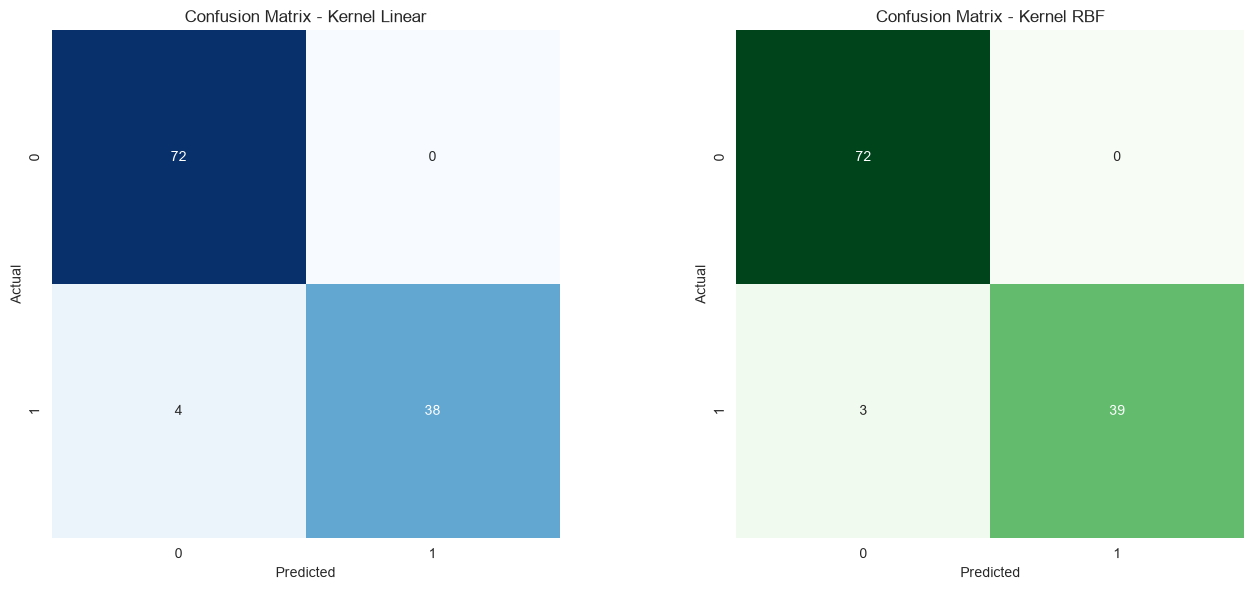

In [42]:
# Tampilkan Confusion Matrix untuk model kernel Linear dan RBF dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.

cm_linear = confusion_matrix(y_test, y_pred_linear)
cm_rbf = confusion_matrix(y_test, y_pred_rbf)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm_linear, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            cbar=False, square=True)
axes[0].set_title('Confusion Matrix - Kernel Linear')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            cbar=False, square=True)
axes[1].set_title('Confusion Matrix - Kernel RBF')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [43]:
# Tampilkan jumlah support vectors dari model dengan performa terbaik.
# Bandingkan jumlah support vectors antara model Linear dan RBF.

n_sv_linear = svm_linear.n_support_
n_sv_rbf = svm_rbf.n_support_

total_sv_linear = svm_linear.support_vectors_.shape[0]
total_sv_rbf = svm_rbf.support_vectors_.shape[0]

print("Support Vectors - Kernel Linear")
print("  Per kelas:", n_sv_linear)
print("  Total    :", total_sv_linear, f"({total_sv_linear / len(y_train) * 100:.2f}% dari data train)")

print("\nSupport Vectors - Kernel RBF")
print("  Per kelas:", n_sv_rbf)
print("  Total    :", total_sv_rbf, f"({total_sv_rbf / len(y_train) * 100:.2f}% dari data train)")

# Tentukan model terbaik berdasarkan akurasi test
if metrics_linear['Accuracy'] >= metrics_rbf['Accuracy']:
    best_model = svm_linear
    best_name = 'Linear'
else:
    best_model = svm_rbf
    best_name = 'RBF'

print(f"\nModel terbaik: SVM kernel {best_name} (Akurasi test = {max(metrics_linear['Accuracy'], metrics_rbf['Accuracy']):.4f})")

Support Vectors - Kernel Linear
  Per kelas: [19 19]
  Total    : 38 (8.35% dari data train)

Support Vectors - Kernel RBF
  Per kelas: [50 57]
  Total    : 107 (23.52% dari data train)

Model terbaik: SVM kernel RBF (Akurasi test = 0.9737)


Explained variance ratio PCA: [0.44593522 0.18545255]
Total explained variance: 0.631387776559559


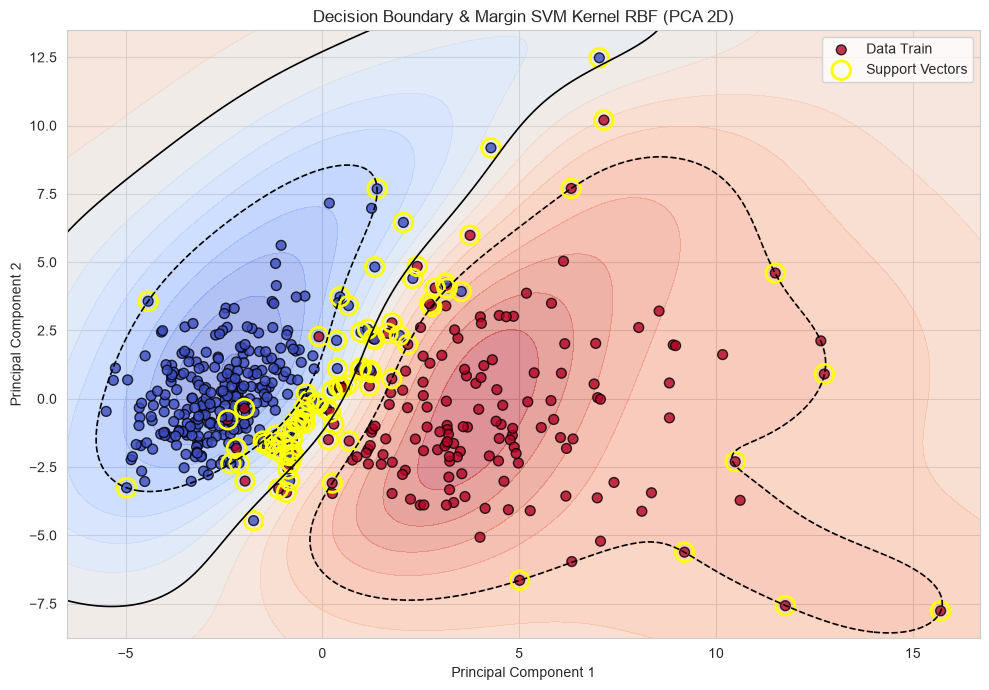

In [45]:
# Reduksi dimensi ke 2D dengan PCA
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Explained variance ratio PCA:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

# Latih ulang model terbaik pada data 2D PCA
best_model_2d = SVC(kernel=best_model.kernel, C=best_model.C,
                    gamma=best_model.gamma if best_model.kernel == 'rbf' else 'scale',
                    random_state=42)
best_model_2d.fit(X_train_pca, y_train)

# Buat mesh grid untuk decision boundary
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

# Pakai decision_function agar bisa gambar margin (-1, 0, 1)
Z_dec = best_model_2d.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z_dec = Z_dec.reshape(xx.shape)

plt.figure(figsize=(10, 7))

# Background decision region
plt.contourf(xx, yy, Z_dec, levels=20, cmap='coolwarm', alpha=0.5)

# Decision boundary (solid) + margin (putus-putus)
plt.contour(xx, yy, Z_dec, colors='k', linewidths=1.2,
            levels=[-1, 0, 1], linestyles=['--', '-', '--'])

# Plot data train
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                      c=y_train, cmap='coolwarm', edgecolors='k',
                      s=50, alpha=0.8, label='Data Train')

# Plot support vectors
sv = best_model_2d.support_vectors_
plt.scatter(sv[:, 0], sv[:, 1], s=180, facecolors='none',
            edgecolors='yellow', linewidths=2, label='Support Vectors')

plt.title(f'Decision Boundary & Margin SVM Kernel {best_name} (PCA 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

## 5. Analisis

### 5.1 Perbandingan Performa SVM Kernel Linear vs RBF

Berdasarkan hasil evaluasi pada test set (20% dari 569 data, yaitu 114 sampel), diperoleh perbandingan metrik sebagai berikut:

| Metrik | Linear | RBF | Selisih |
|---|---|---|---|
| Accuracy | 0.9649 | 0.9737 | +0.0088 |
| Precision | 0.9668 | 0.9747 | +0.0079 |
| Recall | 0.9649 | 0.9737 | +0.0088 |
| F1-Score | 0.9645 | 0.9735 | +0.0090 |

Kedua model sama-sama menunjukkan performa yang sangat tinggi (>96%), namun kernel RBF secara konsisten sedikit lebih unggul di semua metrik, dengan selisih sekitar **0.8–0.9 poin persentase**. Selisih ini memang tidak besar, tetapi **konsisten di seluruh metrik** (Accuracy, Precision, Recall, F1), yang mengindikasikan bahwa keunggulan RBF bukan kebetulan statistik semata.

Perbedaan performa ini dapat dijelaskan dengan mengaitkannya pada bentuk sebaran data dari hasil EDA:

1. **Dari histogram per fitur**, terlihat bahwa fitur-fitur seperti `radius_mean`, `perimeter_mean`, `area_mean`, dan `concavity_mean` memiliki distribusi yang **tumpang tindih (overlap)** antara kelas B (benign) dan M (malignant). Tidak ada satu fitur pun yang benar-benar memisahkan kedua kelas secara bersih dengan satu titik potong linear.

2. **Dari pairplot fitur terpilih**, terlihat bahwa meskipun kelas B (oranye) dan M (biru) cenderung membentuk dua klaster yang berbeda, batas antar keduanya **tidak lurus**. Contohnya pada pasangan `radius_mean` vs `concavity_mean`, kelas M cenderung menyebar ke arah kombinasi nilai tinggi di kedua fitur, sementara kelas B terkonsentrasi di nilai rendah. Pola pemisahan seperti ini lebih menyerupai **kurva** daripada garis lurus.

3. **Dari correlation heatmap**, fitur-fitur yang paling berkorelasi dengan target (`diagnosis_encoded`) adalah `concave points_worst` (0.79), `perimeter_worst` (0.78), `concave points_mean` (0.78), `radius_worst` (0.78), dan `area_worst` (0.74). Nilai korelasi ini kuat tetapi **tidak mencapai 1.0**, artinya masih ada informasi non-linear yang tidak tertangkap oleh hubungan linear sederhana. Korelasi antar fitur juga sangat tinggi (misalnya `radius_mean` vs `perimeter_mean` = 1.00), menunjukkan adanya redundansi dan struktur data yang kompleks.

Kesimpulannya, data Breast Cancer Wisconsin **tidak sepenuhnya linearly separable**. Kernel Linear masih bekerja baik karena data pada dasarnya cukup terpisah (mayoritas sampel B dan M terkonsentrasi di wilayah berbeda), tetapi kernel RBF mampu menangkap **batas keputusan yang lebih fleksibel dan non-linear**, sehingga mampu mengklasifikasikan beberapa sampel borderline yang tidak bisa ditangani kernel Linear. Inilah alasan RBF unggul tipis namun konsisten.

### 5.2 Temuan dari Eksperimen Regularisasi (Nilai C)

Eksperimen variasi nilai C pada kernel RBF dengan `gamma='scale'` menghasilkan data berikut:

| C | Train Acc | Test Acc | Gap (Train − Test) |
|---|---|---|---|
| 0.01 | 0.6264 | 0.6316 | −0.0052 |
| 0.1 | 0.9538 | 0.9474 | +0.0065 |
| 1.0 | 0.9868 | 0.9737 | +0.0131 |
| 10.0 | 0.9890 | 0.9737 | +0.0153 |
| 100.0 | **1.0000** | **0.9649** | **+0.0351** |

Dari tabel dan grafik akurasi train vs test terhadap nilai C (skala logaritmik), dapat diamati tiga fase:

1. **Underfitting pada C = 0.01.** Akurasi train dan test sama-sama rendah (~63%). Model terlalu dibatasi (margin sangat lebar, toleransi kesalahan kecil), sehingga tidak mampu menangkap pola data. Gap negatif kecil (−0.0052) menunjukkan model belum menghafal data training sama sekali.

2. **Konvergensi pada C = 0.1 hingga C = 10.** Akurasi train naik dari 95.38% ke 98.90%, dan akurasi test naik dari 94.74% ke 97.37%. Gap mulai melebar secara perlahan (0.0065 → 0.0153), tetapi masih dalam batas wajar. Model berada di **zona optimal** (good fit) pada kisaran C = 0.1 sampai C = 1.

3. **Gejala overfitting mulai muncul pada C = 100.** Akurasi train mencapai **1.0000 (100%)** — model sempurna menghafal seluruh data training. Namun akurasi test justru **turun** dari 0.9737 (C=10) menjadi 0.9649 (C=100). Gap melebar tajam menjadi **+0.0351**, hampir 3 kali lipat gap pada C=1.

**Ciri-ciri overfitting yang terlihat jelas dari grafik:**
- Akurasi training terus naik secara monoton hingga menyentuh 100%.
- Akurasi testing **stagnan** di C=1 dan C=10 (0.9737), lalu **menurun** di C=100 (0.9649).
- Gap train-test melebar tajam di C=100, menandakan model mulai menghafal noise pada data training alih-alih mempelajari pola general.

**Kesimpulan:** gejala overfitting mulai muncul pada **C = 100**. Nilai C optimal untuk dataset ini berada di kisaran **C = 1 hingga C = 10**, di mana akurasi test tertinggi (97.37%) tercapai tanpa gap yang besar. Nilai C yang terlalu besar membuat model terlalu "keras" terhadap data training (margin sempit, penalti misklasifikasi sangat tinggi), sehingga boundary menjadi sangat spesifik terhadap sampel training dan kehilangan kemampuan generalisasi.

### 5.3 Perbandingan Jumlah Support Vectors (Linear vs RBF)

| Model | SV per Kelas | Total SV | % dari Data Train |
|---|---|---|---|
| Linear | [19, 19] | 38 | 8.35% |
| RBF | [50, 57] | 107 | 23.52% |

Model terbaik secara akurasi test adalah **RBF** (0.9737), dengan total **107 support vectors** (23.52% dari data train). Model Linear hanya membutuhkan **38 support vectors** (8.35% dari data train).

**Hubungan jumlah support vectors dengan kompleksitas batas keputusan:**

1. **Kernel Linear menghasilkan boundary sederhana (hyperplane lurus),** sehingga hanya membutuhkan sedikit titik untuk mendefinisikan margin. Hanya 38 titik (19 per kelas) yang berada di atau dekat margin — sisanya berada jauh dari boundary dan tidak berpengaruh. Ini konsekuensi langsung dari asumsi linearitas: boundary hanya ditentukan oleh posisi beberapa titik terdekat dengan garis pemisah.

2. **Kernel RBF menghasilkan boundary non-linear yang lebih kompleks (melengkung),** sehingga membutuhkan lebih banyak support vectors (107 titik) untuk mendefinisikan bentuk kurva yang mengikuti sebaran data. Setiap support vector memberikan "kontribusi lokal" terhadap bentuk boundary melalui fungsi Gaussian. Semakin banyak support vectors, semakin detail dan fleksibel boundary yang terbentuk.

3. **Proporsi SV yang lebih besar pada RBF (23.52% vs 8.35%)** menunjukkan bahwa data tidak dapat dipisahkan dengan baik hanya oleh beberapa titik kunci. Sebagian besar titik di sekitar boundary (wilayah overlap antar kelas) ikut menentukan bentuk keputusan. Ini konsisten dengan temuan EDA bahwa kedua kelas saling tumpang tindih di beberapa wilayah, sehingga RBF perlu "bekerja lebih keras" untuk memisahkannya.

4. **Trade-off kompleksitas vs generalisasi:** Meskipun RBF menggunakan lebih banyak support vectors (model lebih kompleks), performa test-nya tetap lebih baik dari Linear. Ini menunjukkan bahwa kompleksitas tambahan tersebut **masih relevan** untuk menangkap pola non-linear pada data, dan belum masuk ke wilayah overfitting. Sebaliknya, jika C diperbesar hingga 100, jumlah SV bisa meningkat lebih jauh dan justru menurunkan performa test — inilah titik di mana kompleksitas berubah dari "berguna" menjadi "overfitting".

## 6. Kesimpulan dan Saran

### 6.1 Kesimpulan

Berdasarkan seluruh eksperimen yang telah dilakukan pada dataset Breast Cancer Wisconsin (569 sampel, 30 fitur numerik, 2 kelas: Benign dan Malignant), dapat disimpulkan:

1. **Kernel RBF lebih unggul dibanding kernel Linear** pada dataset ini, dengan akurasi test 97.37% vs 96.49%. Keunggulan ini konsisten di seluruh metrik (Precision, Recall, F1-Score) meskipun selisihnya relatif kecil (~0.9 poin persentase). Hal ini disebabkan karena data **tidak sepenuhnya linearly separable** — terdapat overlap antar kelas dan pola pemisahan yang bersifat non-linear, yang lebih baik ditangkap oleh kernel RBF.

2. **Nilai C optimal berada di kisaran 1 hingga 10.** Pada C = 0.01 model mengalami underfitting (akurasi ~63%). Pada C = 100 model mulai menunjukkan gejala overfitting, dengan akurasi training mencapai 100% namun akurasi testing justru menurun menjadi 96.49% dan gap train-test melebar menjadi 0.0351. Ciri overfitting terlihat dari akurasi training yang terus naik sementara akurasi testing stagnan lalu menurun.

3. **Kernel RBF membutuhkan lebih banyak support vectors (107, 23.52%) dibanding Linear (38, 8.35%).** Ini mencerminkan kompleksitas boundary yang terbentuk: Linear hanya butuh sedikit titik untuk mendefinisikan hyperplane lurus, sedangkan RBF butuh lebih banyak titik untuk membentuk boundary non-linear yang mengikuti sebaran data. Meskipun lebih kompleks, RBF tetap memberikan generalisasi yang lebih baik pada dataset ini.

4. **Feature scaling sangat penting untuk SVM.** Karena SVM berbasis jarak, fitur dengan rentang besar seperti `area_mean` (ratusan hingga ribuan) akan mendominasi fitur dengan rentang kecil seperti `smoothness_mean` (0.05–0.16) jika tidak dinormalisasi. Dengan `StandardScaler`, semua fitur berkontribusi proporsional terhadap pembentukan margin.

5. **PCA 2D terbukti cukup informatif untuk visualisasi decision boundary.** Meskipun hanya menangkap sebagian variance, plot PCA 2D berhasil menunjukkan bentuk boundary non-linear RBF yang melengkung serta posisi support vectors yang menempel di margin — sesuai dengan teori SVM.

### 6.2 Saran

Untuk eksperimen selanjutnya, beberapa hal yang dapat dilakukan:

1. **Hyperparameter tuning dengan GridSearchCV.** Alih-alih mencoba nilai C secara manual, gunakan `GridSearchCV` dengan kombinasi `C` dan `gamma` (misalnya C ∈ {0.1, 1, 10, 100} dan gamma ∈ {0.001, 0.01, 0.1, 1, 'scale'}) untuk menemukan kombinasi optimal secara sistematis. Ini penting karena performa RBF dipengaruhi oleh interaksi antara C dan gamma, bukan hanya C saja.

2. **Mencoba kernel Polynomial.** Kernel polynomial (derajat 2 atau 3) bisa menjadi alternatif menarik untuk membandingkan apakah pendekatan polynomial lebih cocok daripada RBF untuk data ini, sekaligus memperkaya pemahaman tentang pengaruh bentuk kernel terhadap boundary.

3. **Feature selection atau PCA lanjutan.** Karena terdapat korelasi yang sangat tinggi antar fitur (misalnya `radius_mean` vs `perimeter_mean` = 1.00), reduksi fitur dengan PCA (misalnya mempertahankan 95% variance) atau seleksi fitur berbasis korelasi dapat mengurangi redundansi, mempercepat training, dan mungkin meningkatkan generalisasi.

4. **Cross-validation.** Gunakan `StratifiedKFold` cross-validation (misalnya 5-fold) untuk mendapatkan estimasi performa yang lebih stabil dan mengurangi risiko hasil yang kebetulan bagus pada satu split test tertentu.

5. **Perbandingan dengan model lain.** Bandingkan SVM dengan model klasifikasi lain seperti Random Forest, Gradient Boosting (XGBoost/LightGBM), atau Logistic Regression untuk melihat apakah SVM benar-benar model terbaik untuk dataset ini, atau ada alternatif yang lebih sederhana dengan performa setara.

6. **Analisis misklasifikasi.** Periksa sampel-sampel yang salah diklasifikasi oleh model terbaik (RBF) untuk memahami karakteristiknya — apakah mereka berada di wilayah overlap yang memang sulit dipisahkan, atau ada pola lain yang bisa dimanfaatkan untuk perbaikan model.

7. **Handling class imbalance (jika ada).** Meskipun distribusi kelas pada dataset ini tidak terlalu timpang (357 B vs 212 M), penggunaan `class_weight='balanced'` pada SVC bisa dicoba untuk melihat apakah performa pada kelas minoritas (M) bisa lebih ditingkatkan, terutama dari sisi Recall.